In [2]:
import pandas as pd

# 1. Membuat dictionary data
data = {
    'Pauli String': ['X', 'Y', 'Z', 'X', 'Y', 'Z', 'X', 'Y', 'Z', 'X'],
    'Theta (rad)': [-3.14, -2.51, -1.89, -1.26, -0.63, 0.00, 0.63, 1.26, 1.89, 2.51],
    'Ekspektasi Noise': [0.000, -0.349, 0.070, -0.697, 0.349, 0.733, 0.431, -0.216, 0.070, 0.431],
    'Ekspektasi Ideal': [0.000, -0.476, 0.096, -0.951, 0.476, 1.000, 0.588, -0.294, 0.096, 0.588]
}

# 2. Membuat DataFrame
df_hasil = pd.DataFrame(data)

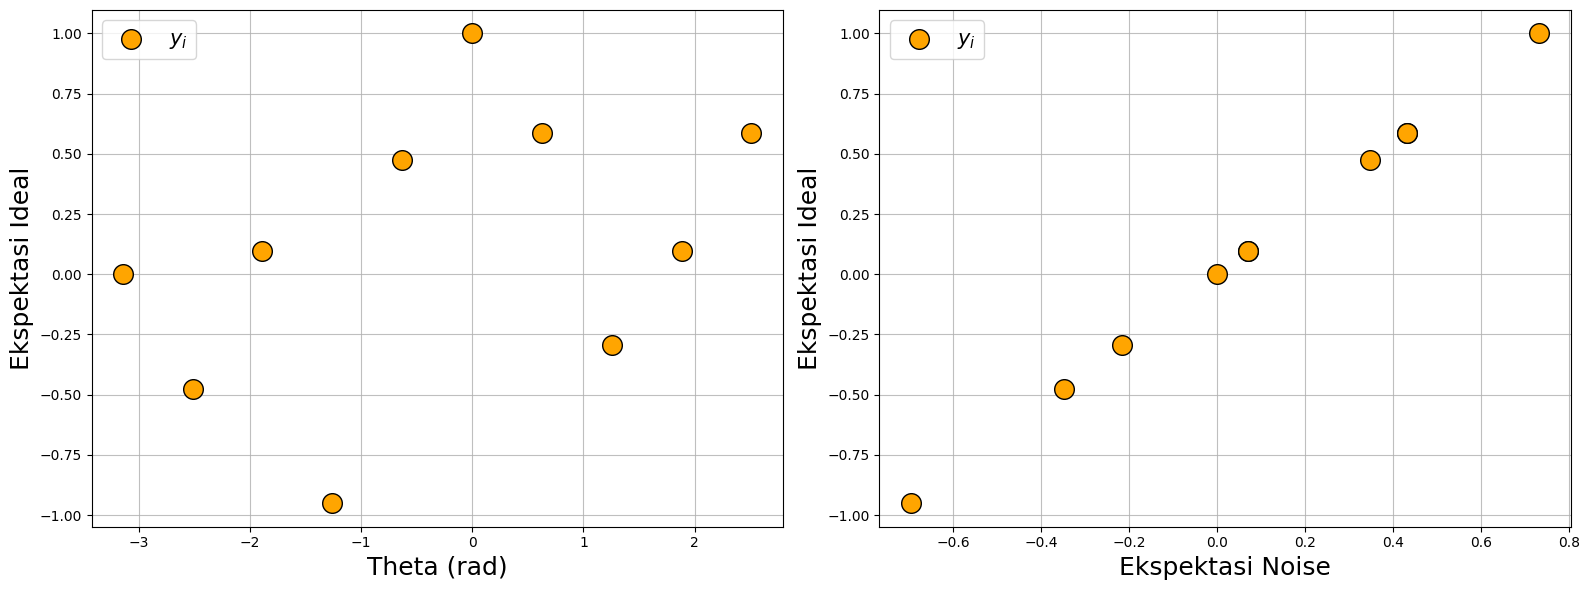

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = df_hasil.copy()

# Fungsi untuk memplot visualisasi RSS
def plot_rss_visual(ax, x_col, y_col, s, title):
    # A. Tentukan Region R1 (Kiri) dan R2 (Kanan) berdasarkan s
    # Sesuai definisi gambar kedua: R1 jika X < s, R2 jika X >= s
    mask_left = df[x_col] < s
    mask_right = df[x_col] >= s
    
    # B. Hitung Rata-rata (y_bar) untuk masing-masing region
    # Ini digunakan dalam rumus RSS (y - y_bar)^2
    mean_left = df.loc[mask_left, y_col].mean()
    mean_right = df.loc[mask_right, y_col].mean()
    
    # Handle jika region kosong (NaN)
    if np.isnan(mean_left): mean_left = 0
    if np.isnan(mean_right): mean_right = 0
    
    # C. Plot Data Points (Scatter)
    ax.scatter(df[x_col], df[y_col], color='orange', label=r'$y_i$', zorder=5, s=200, edgecolor='black')
    
    # D. Plot Garis Vertikal Pemisah (Threshold s)
    # ax.axvline(x=s, color='blue', linestyle='-', linewidth=2, label=f'Split Point (s={s})')
    
    # E. Plot Garis Rata-rata (Horizontal Putus-putus)
    # Garis ini merepresentasikan prediksi model (y_bar) di region tersebut
    x_min, x_max = df[x_col].min(), df[x_col].max()
    margin = (x_max - x_min) * 0.1
    
    # # Rata-rata Kiri (R1)
    # ax.hlines(y=mean_left, xmin=x_min-margin, xmax=s, colors='red', linestyles='--', 
    #           linewidth=2, label=rf'mean R1: {mean_left:.3f}')
    # # Rata-rata Kanan (R2)
    # ax.hlines(y=mean_right, xmin=s, xmax=x_max+margin, colors='green', linestyles='--', 
    #           linewidth=2, label=f'mean R2: {mean_right:.3f}')
    
    # F. Visualisasi Residual (Garis Tegak Lurus)
    # Ini adalah representasi visual dari (yi - y_bar)
    rss_total = 0
    for idx, row in df.iterrows():
        x_val = row[x_col]
        y_val = row[y_col]
        
        if x_val < s:
            target_mean = mean_left
            color = 'red'
        else:
            target_mean = mean_right
            color = 'green'
        
        # Tarik garis dari titik data ke garis rata-rata
        # ax.plot([x_val, x_val], [y_val, target_mean], color=color, alpha=0.6, linewidth=1.5)
        
        # Hitung RSS untuk ditampilkan di title (opsional)
        rss_total += (y_val - target_mean)**2

    ax.set_xlabel(x_col, fontsize=18)
    ax.set_ylabel(y_col, fontsize=18)
    # ax.set_title(f'{title}\nRSS Total: {rss_total:.4f}')
    ax.legend(loc='upper left',fontsize=15)
    ax.grid(True, alpha=0.8)

# --- EKSEKUSI PLOTTING ---

# Setup figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Theta vs Ekspektasi Ideal
# Saya memilih s = 0.0 sebagai contoh split
plot_rss_visual(axes[0], 'Theta (rad)', 'Ekspektasi Ideal', s=data['Theta (rad)'][2], 
                title=r'Plot Ruang Fitur $X_1: \theta$')

# Plot 2: Ekspektasi Noise vs Ekspektasi Ideal
# Saya memilih s = 0.0 sebagai contoh split
plot_rss_visual(axes[1], 'Ekspektasi Noise', 'Ekspektasi Ideal', s=data['Ekspektasi Noise'][2], 
                title=r'Plot Ruang Fitur $X_2:$ noisy exp')

plt.tight_layout()
plt.show()

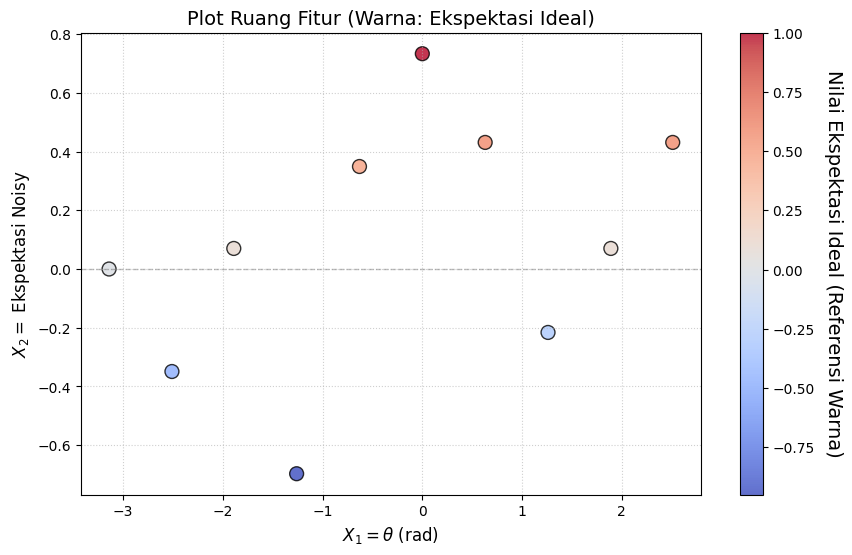

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. PERSIAPAN DATA
# Kita copy dataframe agar data asli aman
df_plot = df_hasil.copy()

# Konversi kolom dari String (format tabel) kembali ke Float (angka)
cols_to_convert = ['Theta (rad)', 'Ekspektasi Ideal', 'Ekspektasi Noise']
for col in cols_to_convert:
    df_plot[col] = df_plot[col].astype(float)

# 2. PLOTTING
plt.figure(figsize=(10, 6))

# Kita gunakan Scatter plot:
# x = Theta
# y = Noisy
# c (color) = Ideal
scatter_plot = plt.scatter(
    df_plot['Theta (rad)'], 
    df_plot['Ekspektasi Noise'], 
    c=df_plot['Ekspektasi Ideal'], # Ini yang mengatur warna berdasarkan nilai Ideal
    cmap='coolwarm',               # Pilihan warna (Biru = -1, Merah = +1)
    s=100,                         # Ukuran titik
    edgecolors='black',            # Garis pinggir titik biar kontras
    alpha=0.8                      # Transparansi sedikit
)

# 3. MENAMBAHKAN COLORBAR
cbar = plt.colorbar(scatter_plot)
cbar.set_label('Nilai Ekspektasi Ideal (Referensi Warna)', rotation=270, labelpad=20, fontsize=14)

# 4. KOSMETIK GRAFIK
plt.title('Plot Ruang Fitur (Warna: Ekspektasi Ideal)', fontsize=14)
plt.xlabel(r'$X_1 = \theta$ (rad)', fontsize=12)
plt.ylabel(r'$X_2 =$ Ekspektasi Noisy', fontsize=12)

# Tambahkan garis bantu (grid) dan garis nol
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(True, linestyle=':', alpha=0.6)

# (Opsional) Menandai mana X dan mana Z dengan teks kecil jika ingin detail
# for i, txt in enumerate(df_plot['Observable']):
#     plt.annotate(txt, (df_plot['Theta (rad)'].iloc[i], df_plot['Ekspektasi Noise'].iloc[i]), xytext=(5,5), textcoords='offset points')

plt.show()

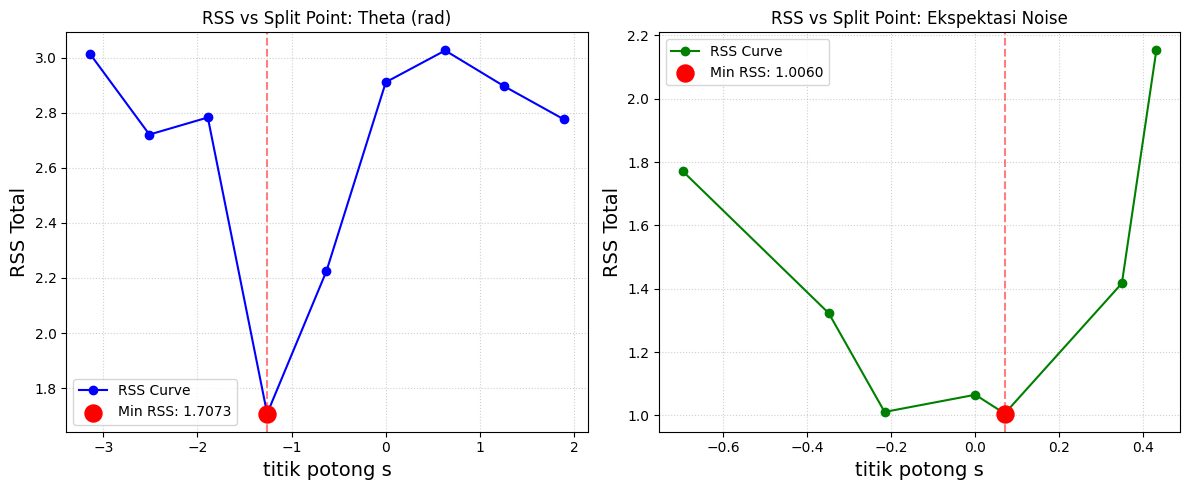

--------------------------------------------------
HASIL ANALISIS SPLIT TERBAIK (DATA USER)
--------------------------------------------------
Fitur: Theta (rad)
  > Cut Point Terbaik : <= -1.26
  > Nilai RSS         : 1.7073
--------------------------------------------------
Fitur: Ekspektasi Noise
  > Cut Point Terbaik : <= 0.07
  > Nilai RSS         : 1.0060
--------------------------------------------------
KESIMPULAN AKHIR: Algoritma akan memilih fitur 'Ekspektasi Noise'
sebagai Root Node karena menghasilkan error (RSS) paling kecil.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = df_hasil.copy()
# 2. FUNGSI HITUNG RSS
def get_rss_curve(feature_col, target_col):
    # Ambil data
    X = df[feature_col].values
    y = df[target_col].values
    
    # Urutkan data berdasarkan fitur agar splitting valid
    sorted_idx = np.argsort(X)
    X_sorted = X[sorted_idx]
    y_sorted = y[sorted_idx]
    
    # Kita akan mencoba memotong di setiap nilai unik yang ada
    # Aturan Split: Left Node <= Threshold, Right Node > Threshold
    unique_vals = np.unique(X_sorted)
    
    thresholds = []
    rss_values = []
    
    # Loop semua nilai unik (kecuali yang paling akhir, karena kanan akan kosong)
    for threshold in unique_vals[:-1]:
        # Lakukan Split
        mask_left = X_sorted <= threshold
        
        y_left = y_sorted[mask_left]
        y_right = y_sorted[~mask_left]
        
        # Hitung RSS (Sum of Squared Residuals)
        # RSS = sum((yi - mean_y)^2)
        rss_left = np.sum((y_left - np.mean(y_left))**2)
        rss_right = np.sum((y_right - np.mean(y_right))**2)
        
        total_rss = rss_left + rss_right
        
        thresholds.append(threshold)
        rss_values.append(total_rss)
        
    return thresholds, rss_values

# 3. PLOTTING
plt.figure(figsize=(12, 5))
features = ['Theta (rad)', 'Ekspektasi Noise']
colors = ['blue', 'green']
best_splits = {}

for i, feature in enumerate(features):
    thresholds, rss_vals = get_rss_curve(feature, 'Ekspektasi Ideal')
    
    # Cari Minimum RSS
    min_idx = np.argmin(rss_vals)
    min_rss = rss_vals[min_idx]
    best_thresh = thresholds[min_idx]
    
    # Simpan info untuk print nanti
    best_splits[feature] = (best_thresh, min_rss)
    
    # Plot Subplot
    plt.subplot(1, 2, i+1)
    plt.plot(thresholds, rss_vals, marker='o', linestyle='-', color=colors[i], label='RSS Curve')
    
    # Tandai titik minimum
    plt.scatter(best_thresh, min_rss, color='red', s=150, zorder=5, label=f'Min RSS: {min_rss:.4f}')
    plt.axvline(best_thresh, color='red', linestyle='--', alpha=0.5)
    
    plt.title(f'RSS vs Split Point: {feature}')
    plt.xlabel(f'titik potong s', fontsize=14)
    plt.ylabel('RSS Total', fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

# 4. KESIMPULAN TEKS
print("-" * 50)
print("HASIL ANALISIS SPLIT TERBAIK (DATA USER)")
print("-" * 50)
for feat in best_splits:
    thresh, rss = best_splits[feat]
    print(f"Fitur: {feat}")
    print(f"  > Cut Point Terbaik : <= {thresh}")
    print(f"  > Nilai RSS         : {rss:.4f}")
    print("-" * 50)

winner = min(best_splits, key=lambda k: best_splits[k][1])
print(f"KESIMPULAN AKHIR: Algoritma akan memilih fitur '{winner}'")
print(f"sebagai Root Node karena menghasilkan error (RSS) paling kecil.")

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --- 2. CLASS DAN FUNGSI TREE ---
class Node:
    def __init__(self, indices, depth=0, rss=0, prediction=0):
        self.indices = indices          # Indeks data yang masuk ke node ini
        self.depth = depth              # Kedalaman node
        self.rss = rss                  # RSS di node ini
        self.prediction = prediction    # Nilai rata-rata target (prediksi)
        self.left = None                # Anak kiri
        self.right = None               # Anak kanan
        self.feature = None             # Fitur pembagi (jika bukan leaf)
        self.threshold = None           # Nilai potong (jika bukan leaf)
        self.is_leaf = False            # Penanda apakah ini daun (Ruang J)

def calculate_rss(y):
    if len(y) == 0: return 0
    mean_y = np.mean(y)
    return np.sum((y - mean_y)**2)

def get_best_split(df, indices, feature_cols, target_col):
    """Mencari fitur dan threshold terbaik untuk membelah data indices."""
    best_rss = float('inf')
    best_split = None
    
    subset = df.iloc[indices]
    
    for feature in feature_cols:
        # Urutkan nilai unik untuk mencoba pemotongan
        unique_vals = np.sort(subset[feature].unique())
        
        # Coba potong di setiap nilai (sebagai threshold <=)
        for threshold in unique_vals[:-1]: 
            left_mask = subset[feature] <= threshold
            right_mask = ~left_mask
            
            y_left = subset.loc[left_mask, target_col]
            y_right = subset.loc[right_mask, target_col]
            
            rss_current = calculate_rss(y_left) + calculate_rss(y_right)
            
            if rss_current < best_rss:
                best_rss = rss_current
                best_split = {
                    'feature': feature,
                    'threshold': threshold,
                    'left_indices': subset[left_mask].index.values,
                    'right_indices': subset[right_mask].index.values,
                    'rss': best_rss
                }
    
    return best_split

def build_tree(df, indices, feature_cols, target_col, depth=0, min_samples_leaf=5):
    """Fungsi Rekursif membangun Tree."""
    y_subset = df.loc[indices, target_col]
    node = Node(indices, depth, calculate_rss(y_subset), np.mean(y_subset))
    
    # Kriteria Berhenti:
    # 1. Jika RSS sudah 0 (murni)
    # 2. Jika jumlah sampel <= min_samples_leaf
    # 3. Jika semua nilai fitur identik (tidak bisa di-split lagi)
    if node.rss == 0 or len(indices) <= min_samples_leaf:
        node.is_leaf = True
        return node
    
    # Cari split terbaik
    split_info = get_best_split(df, indices, feature_cols, target_col)
    
    # Jika tidak ada split yang valid (misal data kembar), jadikan leaf
    if split_info is None:
        node.is_leaf = True
        return node
    
    node.feature = split_info['feature']
    node.threshold = split_info['threshold']
    
    # Rekursif ke anak kiri dan kanan
    node.left = build_tree(df, split_info['left_indices'], feature_cols, target_col, depth+1)
    node.right = build_tree(df, split_info['right_indices'], feature_cols, target_col, depth+1)
    
    return node

# --- 3. EKSEKUSI PEMBUATAN TREE ---
features = ['Theta (rad)', 'Ekspektasi Noise']
root = build_tree(df, df.index.values, features, 'Ekspektasi Ideal')

# --- 4. OUTPUT HASIL (Tekstual) ---
regions = [] # Menyimpan info setiap region (daun)

def print_tree(node, spacing=""):
    if node.is_leaf:
        print(f"{spacing}Region (Leaf): N={len(node.indices)}, Prediksi={node.prediction:.4f}, RSS={node.rss:.4f}")
        regions.append(node)
        return

    print(f"{spacing}Split: [{node.feature} <= {node.threshold:.3f}]")
    print(f"{spacing}--> Left:")
    print_tree(node.left, spacing + "    ")
    print(f"{spacing}--> Right:")
    print_tree(node.right, spacing + "    ")

print("STRUKTUR REGRESSION TREE LENGKAP:")
print("="*40)
print_tree(root)
print("="*40)
print(f"TOTAL RUANG (J) YANG TERBENTUK: {len(regions)}")

STRUKTUR REGRESSION TREE LENGKAP:
Split: [Ekspektasi Noise <= 0.070]
--> Left:
    Split: [Ekspektasi Noise <= -0.349]
    --> Left:
        Region (Leaf): N=2, Prediksi=-0.7135, RSS=0.1128
    --> Right:
        Region (Leaf): N=4, Prediksi=-0.0255, RSS=0.1023
--> Right:
    Region (Leaf): N=4, Prediksi=0.6630, RSS=0.1598
TOTAL RUANG (J) YANG TERBENTUK: 3


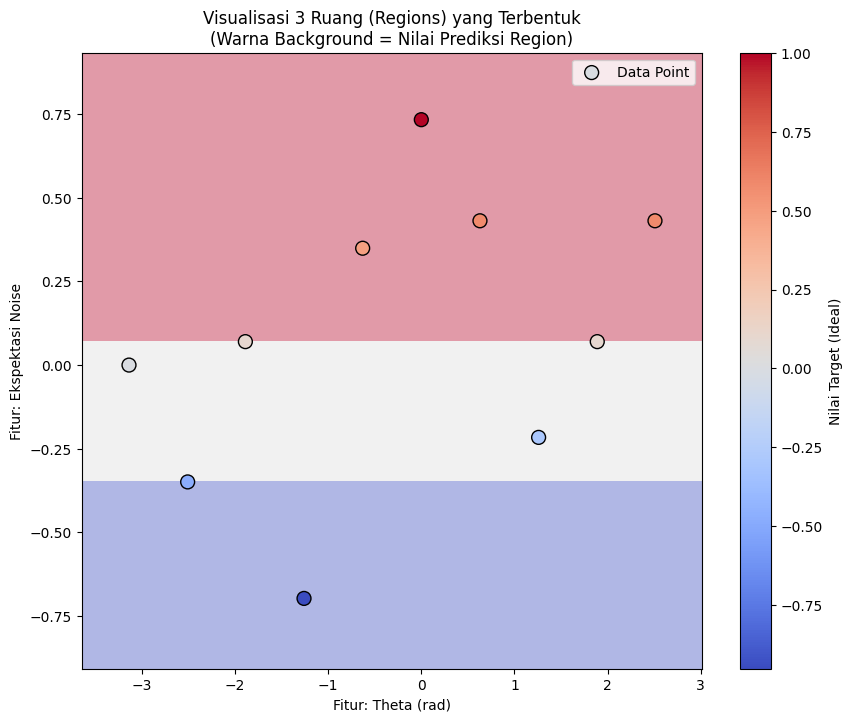

In [7]:
# --- 5. VISUALISASI 2D RUANG (REGIONS) ---
# Note: Visualisasi kotak ini pendekatan sederhana. 
# Untuk plotting decision boundary yang kompleks secara rekursif:

def predict_row(row, node):
    if node.is_leaf:
        return node.prediction
    if row[node.feature] <= node.threshold:
        return predict_row(row, node.left)
    else:
        return predict_row(row, node.right)

# Buat Grid Mesh untuk background warna
x_min, x_max = df['Theta (rad)'].min() - 0.5, df['Theta (rad)'].max() + 0.5
y_min, y_max = df['Ekspektasi Noise'].min() - 0.2, df['Ekspektasi Noise'].max() + 0.2
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Prediksi setiap titik di grid
Z = np.array([predict_row({features[0]: x, features[1]: y}, root) 
              for x, y in zip(xx.ravel(), yy.ravel())])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))

# --- PERBAIKAN DI SINI ---
# Gunakan pcolormesh alih-alih contourf untuk decision boundary yang solid tanpa gap
plt.pcolormesh(xx, yy, Z, cmap='coolwarm', alpha=0.4, shading='auto')

# Plot Data Asli
sc = plt.scatter(df['Theta (rad)'], df['Ekspektasi Noise'], c=df['Ekspektasi Ideal'], 
             edgecolors='k', s=100, cmap='coolwarm', label='Data Point')

plt.colorbar(sc, label='Nilai Target (Ideal)')
plt.title(f'Visualisasi {len(regions)} Ruang (Regions) yang Terbentuk\n(Warna Background = Nilai Prediksi Region)')
plt.xlabel('Fitur: Theta (rad)')
plt.ylabel('Fitur: Ekspektasi Noise')
plt.legend()
plt.show()

In [8]:
import pandas as pd
import numpy as np

# Pastikan df_hasil sudah ada di environment
df = df_hasil.copy()

# --- 1. FUNGSI HITUNG RSS ---
def calculate_rss(y):
    if len(y) == 0: return 0
    mean_y = np.mean(y)
    return np.sum((y - mean_y)**2)

# --- 2. FUNGSI MENAMPILKAN TABEL (DENGAN INDENTASI) ---
def show_rss_calculation_table(df, indices, feature_cols, target_col, prefix_str):
    """
    Menampilkan tabel simulasi RSS dengan indentasi visual agar sejajar dengan tree.
    """
    subset = df.loc[indices].copy()
    
    # Loop fitur untuk hitung simulasi RSS
    for feature in feature_cols:
        col_name = f'RSS_{feature}' # Nama kolom diperpendek agar muat
        rss_values = []
        
        for idx in subset.index:
            threshold = subset.at[idx, feature]
            
            # Simulasi Split
            left_mask = subset[feature] <= threshold
            right_mask = ~left_mask
            
            y_left = subset.loc[left_mask, target_col]
            y_right = subset.loc[right_mask, target_col]
            
            total_rss = calculate_rss(y_left) + calculate_rss(y_right)
            rss_values.append(total_rss)
        
        subset[col_name] = rss_values

    # Formatting Tampilan
    pd.set_option('display.max_rows', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.float_format', '{:.4f}'.format)
    
    ordered_cols = []
    for feat in feature_cols:
        ordered_cols.append(feat)
        ordered_cols.append(f'RSS_{feat}')
    ordered_cols.append(target_col)
    
    # Konversi ke string agar bisa kita beri indentasi manual di setiap baris
    table_str = subset[ordered_cols].to_string()
    
    # Tambahkan indentasi tree (garis vertikal) ke setiap baris tabel
    indented_table = []
    for line in table_str.split('\n'):
        # prefix_str biasanya berupa "│   │   "
        indented_table.append(f"{prefix_str}    {line}") 
    
    print("\n".join(indented_table))
    print(f"{prefix_str}    {'-'*60}")

# --- 3. CLASS NODE ---
class Node:
    def __init__(self, indices, depth=0, rss=0, prediction=0):
        self.indices = indices
        self.depth = depth
        self.rss = rss
        self.prediction = prediction
        self.left = None
        self.right = None
        self.feature = None
        self.threshold = None
        self.is_leaf = False

# --- 4. FUNGSI SPLIT ---
def get_best_split(df, indices, feature_cols, target_col):
    best_rss = float('inf')
    best_split = None
    subset = df.loc[indices]
    
    for feature in feature_cols:
        unique_vals = np.sort(subset[feature].unique())
        for threshold in unique_vals[:-1]: 
            left_mask = subset[feature] <= threshold
            right_mask = ~left_mask
            
            y_left = subset.loc[left_mask, target_col]
            y_right = subset.loc[right_mask, target_col]
            
            rss_current = calculate_rss(y_left) + calculate_rss(y_right)
            
            if rss_current < best_rss:
                best_rss = rss_current
                best_split = {
                    'feature': feature,
                    'threshold': threshold,
                    'left_indices': subset[left_mask].index.values,
                    'right_indices': subset[right_mask].index.values,
                    'rss': best_rss
                }
    return best_split

# --- 5. BUILD TREE (GAYA FILE EXPLORER) ---
def build_tree_file_style(df, indices, feature_cols, target_col, depth=0, min_samples_leaf=5, region_desc="ROOT", prefix="", is_last=True):
    
    y_subset = df.loc[indices, target_col]
    node = Node(indices, depth, calculate_rss(y_subset), np.mean(y_subset))
    
    # --- VISUALISASI TREE STRUCTURE ---
    # Tentukan simbol percabangan (Branch vs Corner)
    # Jika root (depth 0), tidak perlu garis penghubung
    if depth == 0:
        connector = ""
        child_prefix = ""
    else:
        connector = "└── " if is_last else "├── "
        child_prefix = prefix + ("    " if is_last else "│   ")

    # Cetak Header Node
    print(f"{prefix}{connector}📂 [DEPTH {depth}] {region_desc}")
    print(f"{child_prefix}    ℹ️  N={len(indices)} | RSS={node.rss:.4f} | Avg={node.prediction:.4f}")

    # Tampilkan Tabel Analisis (Jika bukan node murni)
    if node.rss > 0 and len(indices) > 1:
        print(f"{child_prefix}    👇 Analisis Split (Tabel RSS):")
        show_rss_calculation_table(df, indices, feature_cols, target_col, child_prefix)
    
    # Kriteria Berhenti
    if node.rss == 0 or len(indices) <= min_samples_leaf:
        node.is_leaf = True
        print(f"{child_prefix}    ✅ LEAF (Selesai).")
        return node
    
    # Cari Split
    split_info = get_best_split(df, indices, feature_cols, target_col)
    
    if split_info is None:
        node.is_leaf = True
        print(f"{child_prefix}    ⚠️ LEAF (Tidak bisa split).")
        return node
    
    node.feature = split_info['feature']
    node.threshold = split_info['threshold']
    
    print(f"{child_prefix}    ✂️  KEPUTUSAN: Potong di [{node.feature} <= {node.threshold}]")
    
    # --- REKURSI (LEFT & RIGHT) ---
    # Left Child (biasanya bukan yang terakhir, jadi is_last=False)
    # Kecuali jika nanti kita pakai strategi lain, tapi standar tree: Left dulu baru Right
    
    left_desc = f"KIRI ({node.feature} <= {node.threshold})"
    node.left = build_tree_file_style(
        df, split_info['left_indices'], feature_cols, target_col, 
        depth+1, min_samples_leaf, left_desc, 
        prefix=child_prefix, is_last=False
    )
    
    right_desc = f"KANAN ({node.feature} > {node.threshold})"
    node.right = build_tree_file_style(
        df, split_info['right_indices'], feature_cols, target_col, 
        depth+1, min_samples_leaf, right_desc, 
        prefix=child_prefix, is_last=True
    )
    
    return node

# --- EKSEKUSI ---
features = ['Theta (rad)', 'Ekspektasi Noise']
target = 'Ekspektasi Ideal'

print("VISUALISASI PROSES TREE (FILE STYLE):\n")
root = build_tree_file_style(df, df.index.values, features, target)

VISUALISASI PROSES TREE (FILE STYLE):

📂 [DEPTH 0] ROOT
    ℹ️  N=10 | RSS=3.0278 | Avg=0.1123
    👇 Analisis Split (Tabel RSS):
       Theta (rad)  RSS_Theta (rad)  Ekspektasi Noise  RSS_Ekspektasi Noise  Ekspektasi Ideal
    0      -3.1400           3.0138            0.0000                1.0654            0.0000
    1      -2.5100           2.7210           -0.3490                1.3229           -0.4760
    2      -1.8900           2.7831            0.0700                1.0060            0.0960
    3      -1.2600           1.7073           -0.6970                1.7716           -0.9510
    4      -0.6300           2.2252            0.3490                1.4172            0.4760
    5       0.0000           2.9113            0.7330                3.0278            1.0000
    6       0.6300           3.0265            0.4310                2.1522            0.5880
    7       1.2600           2.8959           -0.2160                1.0112           -0.2940
    8       1.8900       

In [12]:
import numpy as np
import pandas as pd

def get_pauli(label):
    """Mengembalikan matriks Pauli berdasarkan label."""
    if label == 'x':
        return np.array([[0, 1], [1, 0]], dtype=complex)
    elif label == 'y':
        return np.array([[0, -1j], [1j, 0]], dtype=complex)
    elif label == 'z':
        return np.array([[1, 0], [0, -1]], dtype=complex)
    return None

def get_rx(phi):
    """Mengembalikan matriks rotasi Rx sebesar phi."""
    return np.array([
        [np.cos(phi / 2), -1j * np.sin(phi / 2)],
        [-1j * np.sin(phi / 2),  np.cos(phi / 2)]
    ], dtype=complex)

def hitung_data_tabel_unik(n_rows=10, error_prob=0.2,observables = ['x','y','z']):
    # Definisi Matriks Dasar
    ket_0 = np.array([[1], [0]], dtype=complex)
    thetas = np.arange(-np.pi, np.pi,2*np.pi/n_rows)

    # Matriks Pauli untuk Error
    sigma_x = get_pauli('x')
    sigma_y = get_pauli('y')
    sigma_z = get_pauli('z')

    data_rows = []
    

    # --- LOOP UTAMA (Satu baris = Satu Theta Unik) ---
    for i in range(n_rows):
        
        # 1. Pilih Observable secara bergantian (x, y, z, x, y, z...)
        obs_label = observables[i % len(observables)]
        
        # 2. Generate Theta & Phi Acak UNTUK BARIS INI SAJA
        theta = thetas[i]
        phi = theta # Mengikuti logika kode sebelumnya (phi = theta)
        
        # 3. --- State Preparation (Ansatz: Ry -> Rx) ---
        ry = np.array([
            [np.cos(theta / 2), -np.sin(theta / 2)],
            [np.sin(theta / 2),  np.cos(theta / 2)]
        ], dtype=complex)
        
        rx = get_rx(phi)
        
        # State Ideal: psi = Rx * Ry * |0>
        psi_step1 = np.dot(ry, ket_0)
        psi_ideal = np.dot(rx, psi_step1)
        
        # 4. --- State Error (Depolarizing Channel) ---
        psi_err_x = np.dot(sigma_x, psi_ideal)
        psi_err_y = np.dot(sigma_y, psi_ideal)
        psi_err_z = np.dot(sigma_z, psi_ideal)

        # 5. --- Hitung Nilai Ekspektasi ---
        H = get_pauli(obs_label)
        
        # A. Nilai Ekspektasi Ideal
        val_ideal = np.dot(psi_ideal.conj().T, np.dot(H, psi_ideal)).item().real
        
        # B. Nilai Ekspektasi komponen error
        val_x = np.dot(psi_err_x.conj().T, np.dot(H, psi_err_x)).item().real
        val_y = np.dot(psi_err_y.conj().T, np.dot(H, psi_err_y)).item().real
        val_z = np.dot(psi_err_z.conj().T, np.dot(H, psi_err_z)).item().real
        
        # C. Hitung Gabungan (Depolarizing Formula)
        val_noisy = ((1 - error_prob) * val_ideal) + \
                    ((error_prob / 3.0) * (val_x + val_y + val_z))

        # Simpan ke list
        data_rows.append({
            "pauli string": obs_label.upper(),
            "Theta (rad)": float(theta), # Setiap baris punya theta beda
            "Phi (Rx)": float(phi),
            "Ekspektasi Ideal": float(val_ideal),
            "Ekspektasi Noise": float(val_noisy),
        })

    # Buat DataFrame
    df = pd.DataFrame(data_rows)
    return df

# --- EKSEKUSI ---
# n_rows=15 berarti kita akan punya 5 set (x,y,z) tapi semuanya dengan sudut berbeda
df_hasil = hitung_data_tabel_unik(n_rows=10, error_prob=0.2)

# Tampilkan Tabel
pd.options.display.float_format = '{:.4f}'.format
print("Tabel Ekspektasi dengan Theta Unik per Baris")
print("=" * 110)
print(df_hasil.to_string(index=False))
print("=" * 110)

Tabel Ekspektasi dengan Theta Unik per Baris
pauli string  Theta (rad)  Phi (Rx)  Ekspektasi Ideal  Ekspektasi Noise
           X      -3.1416   -3.1416           -0.0000           -0.0000
           Y      -2.5133   -2.5133           -0.4755           -0.3487
           Z      -1.8850   -1.8850            0.0955            0.0700
           X      -1.2566   -1.2566           -0.9511           -0.6974
           Y      -0.6283   -0.6283            0.4755            0.3487
           Z       0.0000    0.0000            1.0000            0.7333
           X       0.6283    0.6283            0.5878            0.4310
           Y       1.2566    1.2566           -0.2939           -0.2155
           Z       1.8850    1.8850            0.0955            0.0700
           X       2.5133    2.5133            0.5878            0.4310


In [45]:

df= hitung_data_tabel_unik(error_prob=0.2, observables=['z']).round(2)
df

,pauli string,Theta (rad),Phi (Rx),Ekspektasi Ideal,Ekspektasi Noise
0,Z,-3.1400,-3.1400,1.0000,0.7300
1,Z,-2.5100,-2.5100,0.6500,0.4800
2,Z,-1.8800,-1.8800,0.1000,0.0700
3,Z,-1.2600,-1.2600,0.1000,0.0700
4,Z,-0.6300,-0.6300,0.6500,0.4800
5,Z,0.0000,0.0000,1.0000,0.7300
6,Z,0.6300,0.6300,0.6500,0.4800
7,Z,1.2600,1.2600,0.1000,0.0700
8,Z,1.8800,1.8800,0.1000,0.0700
9,Z,2.5100,2.5100,0.6500,0.4800


In [66]:
import numpy as np
import pandas as pd

# --- 1. FUNGSI PREDIKSI ---
# Menggunakan fungsi traverse yang sama seperti sebelumnya
def get_prediction(row, node):
    # Jika sampai di daun, kembalikan nilai prediksi daun
    if node.is_leaf:
        return node.prediction
    
    # Jika belum daun, cek fitur dan threshold
    val = row[node.feature]
    if val <= node.threshold:
        return get_prediction(row, node.left)
    else:
        return get_prediction(row, node.right)

# --- 2. LAKUKAN PREDIKSI KE SELURUH DATA ---
y_actual = df['Ekspektasi Ideal'].values
y_pred_list = []

for index, row in df.iterrows():
    pred = get_prediction(row, root)
    y_pred_list.append(pred)

y_pred = np.array(y_pred_list)

# --- 3. HITUNG METRIK MAE & MSE ---

# MAE: Rata-rata selisih mutlak
mae = np.mean(np.abs(y_actual - y_pred))

# MSE: Rata-rata kuadrat selisih
mse = np.mean((y_actual - y_pred)**2)

# RMSE: Akar dari MSE (Opsional, agar satuannya sama dengan target)
rmse = np.sqrt(mse)

# --- 4. TAMPILKAN HASIL ---
print("="*40)
print("EVALUASI PERFORMA MODEL (TRAINING SET)")
print("="*40)

# Tampilkan perbandingan data asli vs prediksi
comparison_df = pd.DataFrame({
    'pauli string' : df['pauli string'],
    'Theta': df['Theta (rad)'],
    'Ekspektasi Noise': df['Ekspektasi Noise'],
    'Ekspektasi Ideal': y_actual,
    'Prediksi Model': y_pred,
    'Error (%)': (np.abs(y_actual - y_pred)*100)
})

print("Tabel Perbandingan (5 Baris Pertama):")
print(comparison_df.to_string(index=False))
print("-" * 40)
print(f"Mean Absolute Error (MAE) : {mae:.10f}")
print(f"Mean Squared Error (MSE)  : {mse:.10f}")
print(f"Root Mean Squared Error   : {rmse:.10f}")
print("="*40)

if mse < 1e-9:
    print("KESIMPULAN: Error sangat mendekati 0.")
    print("Model telah 'menghafal' data training dengan sempurna (Overfitting).")

EVALUASI PERFORMA MODEL (TRAINING SET)
Tabel Perbandingan (5 Baris Pertama):
pauli string   Theta  Ekspektasi Noise  Ekspektasi Ideal  Prediksi Model  Error (%)
           X -3.1416           -0.0000           -0.0000         -0.0257     2.5727
           Y -2.5133           -0.3487           -0.4755         -0.7133    23.7764
           Z -1.8850            0.0700            0.0955         -0.0257    12.1219
           X -1.2566           -0.6974           -0.9511         -0.7133    23.7764
           Y -0.6283            0.3487            0.4755          0.6628    18.7246
           Z  0.0000            0.7333            1.0000          0.6628    33.7225
           X  0.6283            0.4310            0.5878          0.6628     7.4989
           Y  1.2566           -0.2155           -0.2939         -0.0257    26.8165
           Z  1.8850            0.0700            0.0955         -0.0257    12.1219
           X  2.5133            0.4310            0.5878          0.6628     7.4989